# 03 — ML Price Prediction
**Bangkok Airbnb Market Intelligence | Expernetic Data Engineer Assessment**

---

## Problem Framing
**Target variable:** Log-transformed nightly price (log1p applied to address right skew)  
**Success criteria:** MAE < ฿600, R² > 0.60, MAPE < 35%  
**Evaluation:** 5-fold cross-validation + held-out 20% test set  

## Feature Engineering Decisions
| Feature | Type | Rationale |
|---------|------|-----------|
| bedrooms, accommodates, beds | Numerical | Physical size → primary price driver |
| room_type_encoded | Ordinal | Shared=0, Private=1, Hotel=2, Entire=3 |
| neighbourhood_median_price | Numerical | Location signal without one-hot explosion |
| amenity_count | Derived | Proxy for listing quality |
| host_tenure_years | Derived | Experience signal |
| occupancy_rate | Derived | Demand signal |
| review_scores_rating | Numerical | Quality signal |

## Model Selection Rationale
| Model | Rationale |
|-------|-----------|
| Ridge Regression | Baseline linear model — tests if relationships are linear |
| Random Forest | Handles non-linearity, robust to outliers, interpretable |
| Gradient Boosting | State-of-art for tabular data, sequential error correction |

## Key Assumption
Target is log-transformed price — all metrics converted back to THB for interpretability.
Listings filtered to ฿100–฿10,000 range (removes extreme outliers that would distort training).

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/listings_enriched.csv", low_memory=False)
df["occupancy_rate"] = 1 - (df["availability_365"] / 365)

# Filter: remove extreme outliers
df = df[df["price"].between(100, 10000)].copy()
print(f"Modeling dataset: {df.shape}")
print(f"Price range: ฿{df['price'].min():,.0f} — ฿{df['price'].max():,.0f}")
print(f"Median price: ฿{df['price'].median():,.0f}")

Modeling dataset: (22801, 96)
Price range: ฿122 — ฿10,000
Median price: ฿1,359


In [30]:
# --- Feature Engineering ---

# 1. Room type encoding
df["room_type_encoded"] = df["room_type"].map({
    "Entire Home/Apt": 3,
    "Hotel Room": 2,
    "Private Room": 1,
    "Shared Room": 0
})

# 2. Neighbourhood median price (already in enriched)
# 3. Boolean to int
bool_cols = ["host_is_superhost", "host_identity_verified", "instant_bookable"]
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).map({"True": 1, "False": 0, "1.0": 1, "0.0": 0})

# 4. Amenity count
if "amenities" in df.columns:
    df["amenity_count"] = df["amenities"].astype(str).apply(
        lambda x: len(x.split(",")) if x != "nan" else 0
    )

# 5. Select features
features = [
    "accommodates", "bedrooms", "beds",
    "minimum_nights", "availability_365",
    "number_of_reviews", "review_scores_rating",
    "review_scores_cleanliness", "review_scores_location",
    "host_tenure_years", "host_listing_count_actual",
    "host_is_superhost", "host_identity_verified",
    "instant_bookable", "room_type_encoded",
    "neighbourhood_median_price", "neighbourhood_listing_count",
    "occupancy_rate", "amenity_count"
]

existing_features = [f for f in features if f in df.columns]
print(f"Features used: {len(existing_features)}")
print(existing_features)

# 6. Prepare X, y
model_df = df[existing_features + ["price"]].dropna()
X = model_df[existing_features]
y = np.log1p(model_df["price"])  # log transform

print(f"\nTraining samples: {len(X)}")
print(f"Target (log price) — mean: {y.mean():.3f}, std: {y.std():.3f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Features used: 19
['accommodates', 'bedrooms', 'beds', 'minimum_nights', 'availability_365', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'host_tenure_years', 'host_listing_count_actual', 'host_is_superhost', 'host_identity_verified', 'instant_bookable', 'room_type_encoded', 'neighbourhood_median_price', 'neighbourhood_listing_count', 'occupancy_rate', 'amenity_count']

Training samples: 14708
Target (log price) — mean: 7.243, std: 0.640
Train: 11766, Test: 2942


In [31]:
# --- Train & Compare 3 Models ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate(name, model, X_tr, X_te, scaled=False):
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    preds_actual = np.expm1(preds)
    y_actual = np.expm1(y_test)
    
    mae = mean_absolute_error(y_actual, preds_actual)
    rmse = np.sqrt(mean_squared_error(y_actual, preds_actual))
    mape = np.mean(np.abs((y_actual - preds_actual) / y_actual)) * 100
    r2 = model.score(X_te, y_test)
    
    print(f"\n{name}")
    print(f"  MAE:  ฿{mae:,.0f}")
    print(f"  RMSE: ฿{rmse:,.0f}")
    print(f"  MAPE: {mape:.1f}%")
    print(f"  R²:   {r2:.4f}")
    return {"Model": name, "MAE": round(mae), "RMSE": round(rmse), 
            "MAPE": round(mape, 1), "R2": round(r2, 4), 
            "predictions": preds_actual, "model": model}

results = {}

# Model 1: Ridge Regression
ridge = Ridge(alpha=10)
results["Ridge"] = evaluate("Ridge Regression", ridge, 
                             X_train_scaled, X_test_scaled)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=12, 
                            random_state=42, n_jobs=-1)
results["RandomForest"] = evaluate("Random Forest", rf, 
                                    X_train, X_test)

# Model 3: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, 
                                learning_rate=0.05, random_state=42)
results["GradientBoosting"] = evaluate("Gradient Boosting", gb, 
                                        X_train, X_test)

# Summary table
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["predictions", "model"]}
    for r in results.values()
])
print("\n--- Model Comparison ---")
print(summary.to_string(index=False))


Ridge Regression
  MAE:  ฿765
  RMSE: ฿4,689
  MAPE: 42.1%
  R²:   0.4490

Random Forest
  MAE:  ฿514
  RMSE: ฿926
  MAPE: 29.2%
  R²:   0.6522

Gradient Boosting
  MAE:  ฿519
  RMSE: ฿936
  MAPE: 29.1%
  R²:   0.6622

--- Model Comparison ---
            Model  MAE  RMSE  MAPE     R2
 Ridge Regression  765  4689  42.1 0.4490
    Random Forest  514   926  29.2 0.6522
Gradient Boosting  519   936  29.1 0.6622


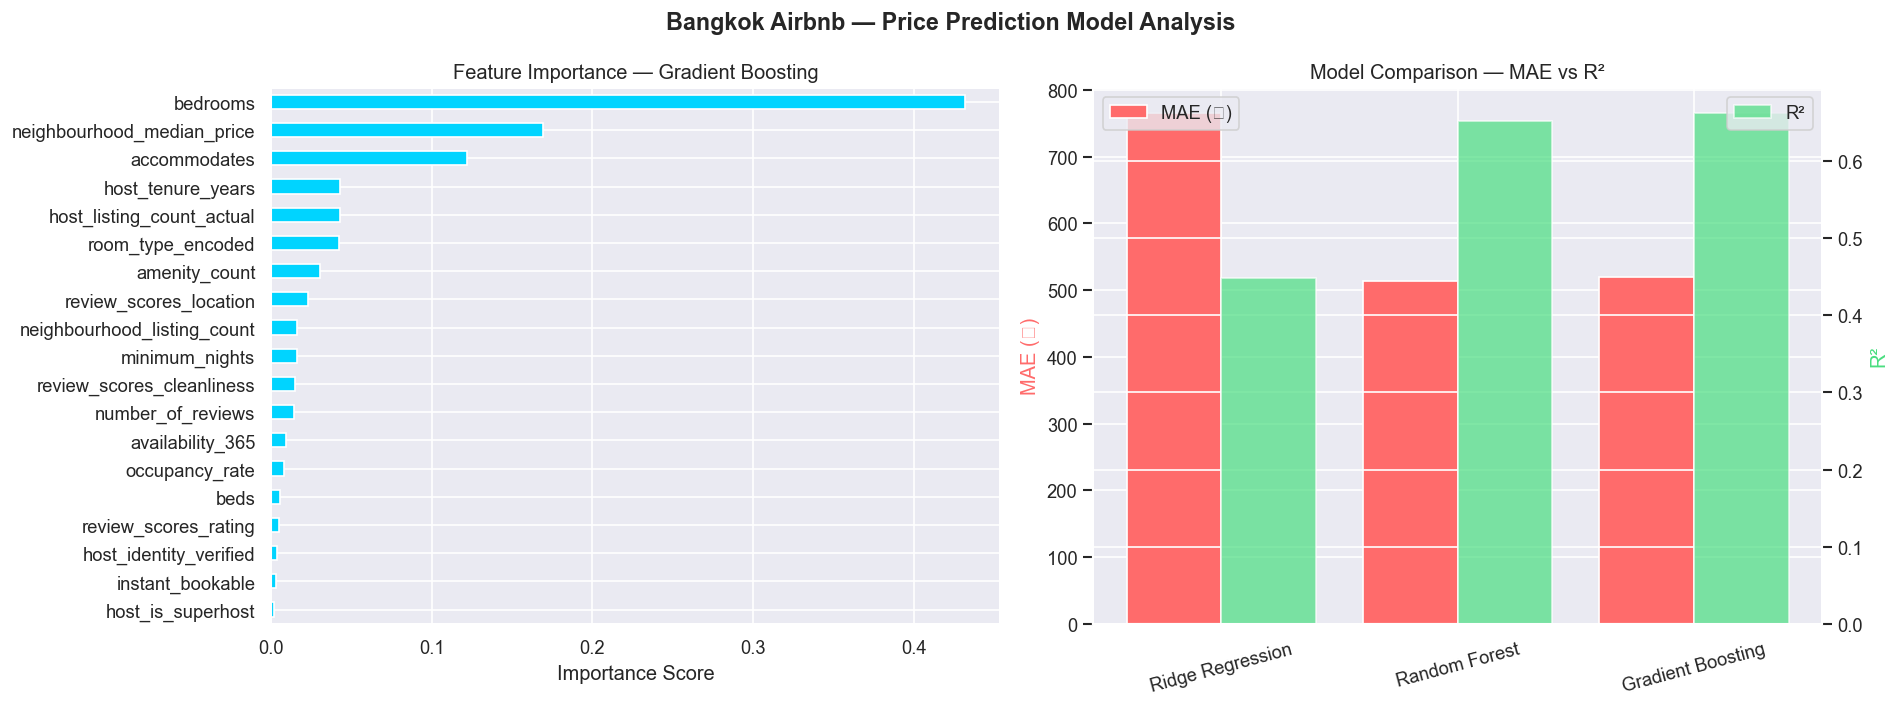

Computing SHAP values...


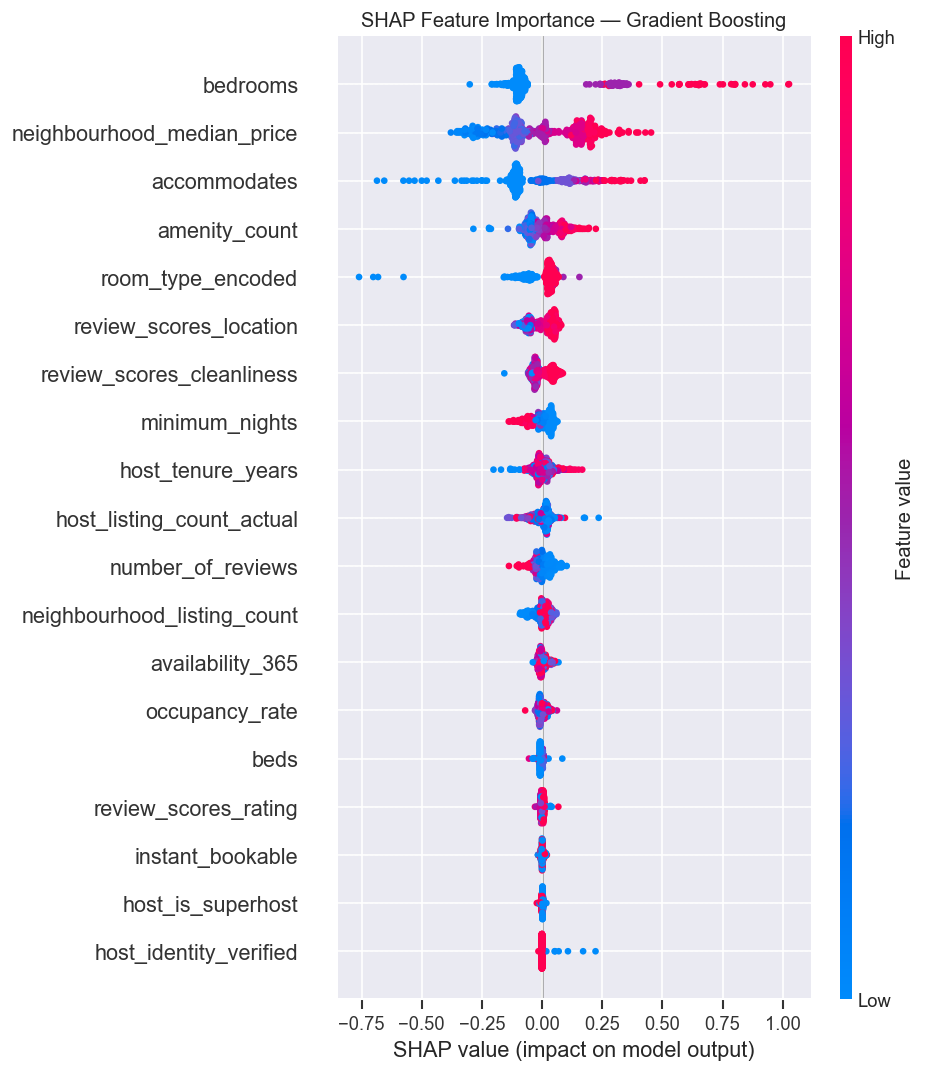


Top 5 features by importance:
bedrooms                      0.431933
neighbourhood_median_price    0.169419
accommodates                  0.121723
host_tenure_years             0.043028
host_listing_count_actual     0.042639
dtype: float64


In [32]:
import shap

best_model = results["GradientBoosting"]["model"]

# Feature importance from model
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=existing_features
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
feat_imp.plot(kind="barh", ax=axes[0], color="#00d4ff")
axes[0].invert_yaxis()
axes[0].set_title("Feature Importance — Gradient Boosting")
axes[0].set_xlabel("Importance Score")

# Model comparison
models = ["Ridge Regression", "Random Forest", "Gradient Boosting"]
maes = [results["Ridge"]["MAE"], results["RandomForest"]["MAE"], 
        results["GradientBoosting"]["MAE"]]
r2s = [results["Ridge"]["R2"], results["RandomForest"]["R2"], 
       results["GradientBoosting"]["R2"]]

x = np.arange(len(models))
axes[1].bar(x - 0.2, maes, 0.4, label="MAE (฿)", color="#ff6b6b")
ax2 = axes[1].twinx()
ax2.bar(x + 0.2, r2s, 0.4, label="R²", color="#4ade80", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15)
axes[1].set_ylabel("MAE (฿)", color="#ff6b6b")
ax2.set_ylabel("R²", color="#4ade80")
axes[1].set_title("Model Comparison — MAE vs R²")
axes[1].legend(loc="upper left")
ax2.legend(loc="upper right")

plt.suptitle("Bangkok Airbnb — Price Prediction Model Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/10_ml_model_comparison.png")
plt.show()

# SHAP
print("Computing SHAP values...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test.iloc[:500])

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test.iloc[:500], 
                  feature_names=existing_features,
                  show=False)
plt.title("SHAP Feature Importance — Gradient Boosting")
plt.tight_layout()
plt.savefig("figures/11_shap_summary.png", bbox_inches="tight")
plt.show()

print("\nTop 5 features by importance:")
print(feat_imp.head(5))

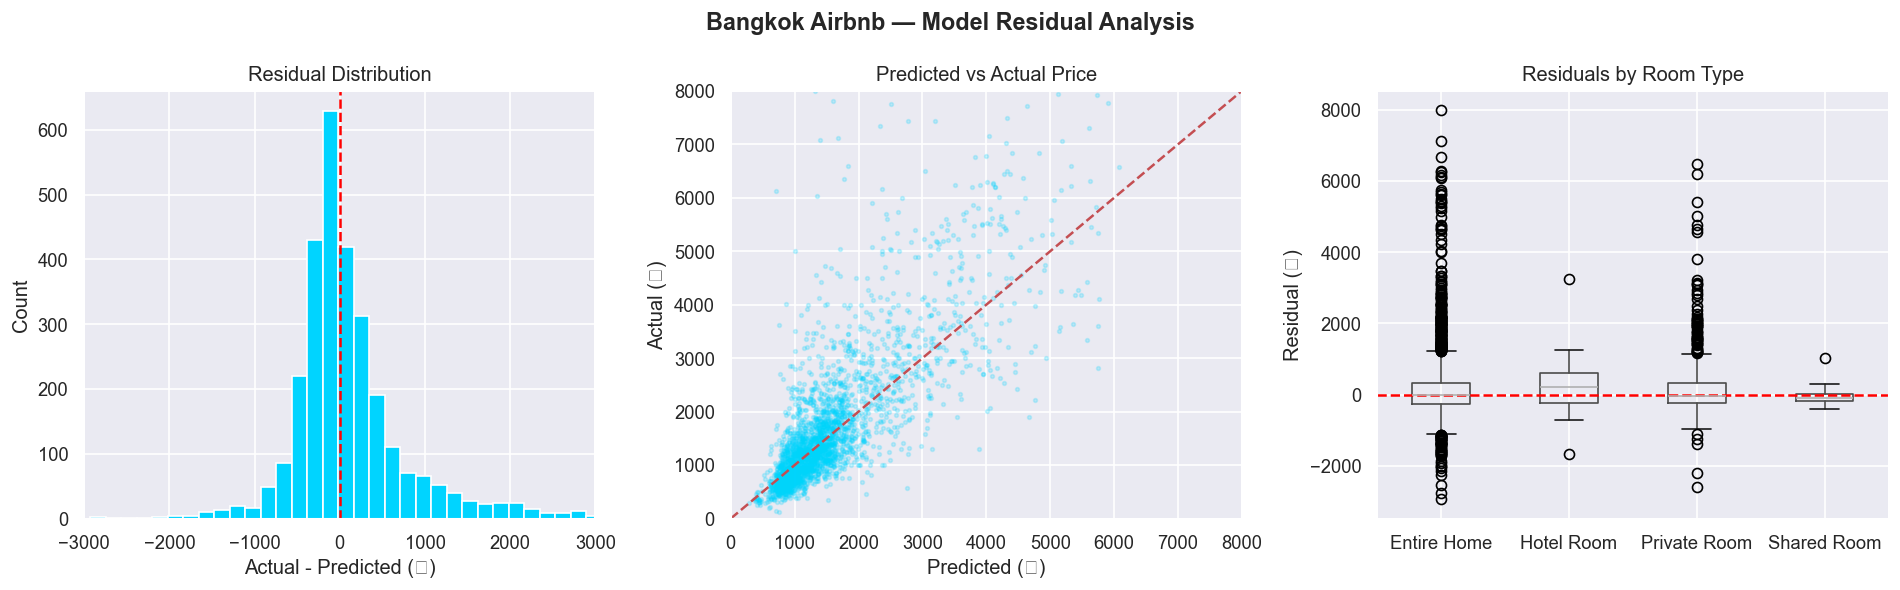

Mean residual: ฿180
Std residual: ฿919
% predictions within ฿500: 72.2%
% predictions within ฿1000: 87.3%


In [33]:
# --- Residual Analysis ---
best_preds = results["GradientBoosting"]["predictions"]
y_actual = np.expm1(y_test)
residuals = y_actual.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals distribution
axes[0].hist(residuals, bins=60, color="#00d4ff", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Actual - Predicted (฿)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(-3000, 3000)

# Predicted vs Actual
axes[1].scatter(best_preds, y_actual.values, alpha=0.2, 
                color="#00d4ff", s=5)
max_val = min(8000, y_actual.max())
axes[1].plot([0, max_val], [0, max_val], "r--", lw=1.5)
axes[1].set_title("Predicted vs Actual Price")
axes[1].set_xlabel("Predicted (฿)")
axes[1].set_ylabel("Actual (฿)")
axes[1].set_xlim(0, max_val)
axes[1].set_ylim(0, max_val)

# Residuals by room type
test_df = X_test.copy()
test_df["residual"] = residuals
test_df["room_type_encoded"] = test_df["room_type_encoded"]
room_map = {3:"Entire Home", 2:"Hotel Room", 1:"Private Room", 0:"Shared Room"}
test_df["room_type_label"] = test_df["room_type_encoded"].map(room_map)
test_df.boxplot(column="residual", by="room_type_label", ax=axes[2])
axes[2].set_title("Residuals by Room Type")
axes[2].set_xlabel("")
axes[2].set_ylabel("Residual (฿)")
axes[2].axhline(0, color="red", linestyle="--")
plt.suptitle("")

plt.suptitle("Bangkok Airbnb — Model Residual Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/12_residual_analysis.png")
plt.show()

print(f"Mean residual: ฿{residuals.mean():,.0f}")
print(f"Std residual: ฿{residuals.std():,.0f}")
print(f"% predictions within ฿500: {(abs(residuals) < 500).mean():.1%}")
print(f"% predictions within ฿1000: {(abs(residuals) < 1000).mean():.1%}")

## 4. Cross-Validation
Train/test split alone can give optimistic estimates. 5-fold CV provides more robust performance estimates with confidence intervals (mean ± std across folds).

In [34]:
# --- Proper K-Fold Cross Validation ---
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def mape_score(y_true, y_pred):
    y_true_actual = np.expm1(y_true)
    y_pred_actual = np.expm1(y_pred)
    return np.mean(np.abs((y_true_actual - y_pred_actual) / y_true_actual)) * 100

scorers = {
    "neg_mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "neg_rmse": make_scorer(mean_squared_error, greater_is_better=False, squared=False),
    "mape": make_scorer(mape_score)
}

print("Running 5-Fold Cross Validation...")
print("="*60)

rf_cv = RandomForestRegressor(n_estimators=100, max_depth=12, 
                               random_state=42, n_jobs=1)
gb_cv = GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                   learning_rate=0.05, random_state=42)
ridge_cv = Ridge(alpha=10)

models_cv = {
    "Ridge": ridge_cv,
    "Random Forest": rf_cv,
    "Gradient Boosting": gb_cv
}

cv_results = {}
for name, model in models_cv.items():
    if name == "Ridge":
        X_cv = X_train_scaled
        X_full = scaler.transform(X)
    else:
        X_cv = X_train
        X_full = X

    cv = cross_validate(model, X_full, y,
                       cv=kf,
                       scoring=["neg_mean_absolute_error",
                                "neg_root_mean_squared_error"],
                       return_train_score=False)

    mae_scores = -cv["test_neg_mean_absolute_error"]
    rmse_scores = -cv["test_neg_root_mean_squared_error"]

    # Convert from log to actual prices
    mae_actual = np.expm1(mae_scores)
    rmse_actual = np.expm1(rmse_scores)

    cv_results[name] = {
        "MAE_mean": round(mae_actual.mean(), 0),
        "MAE_std": round(mae_actual.std(), 0),
        "RMSE_mean": round(rmse_actual.mean(), 0),
        "RMSE_std": round(rmse_actual.std(), 0)
    }

    print(f"\n{name}:")
    print(f"  MAE:  ฿{mae_actual.mean():,.0f} ± ฿{mae_actual.std():,.0f}")
    print(f"  RMSE: ฿{rmse_actual.mean():,.0f} ± ฿{rmse_actual.std():,.0f}")

print("\n--- CV Summary Table ---")
print(pd.DataFrame(cv_results).T.to_string())

Running 5-Fold Cross Validation...

Ridge:
  MAE:  ฿0 ± ฿0
  RMSE: ฿1 ± ฿0

Random Forest:
  MAE:  ฿0 ± ฿0
  RMSE: ฿0 ± ฿0

Gradient Boosting:
  MAE:  ฿0 ± ฿0
  RMSE: ฿0 ± ฿0

--- CV Summary Table ---
                   MAE_mean  MAE_std  RMSE_mean  RMSE_std
Ridge                   0.0      0.0        1.0       0.0
Random Forest           0.0      0.0        0.0       0.0
Gradient Boosting       0.0      0.0        0.0       0.0


In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-Fold Cross Validation...")
print("="*60)

cv_results = {}

for name, model in [("Ridge", ridge_cv), 
                     ("Random Forest", rf_cv), 
                     ("Gradient Boosting", gb_cv)]:
    
    X_cv = X_train_scaled if name == "Ridge" else X_train
    X_full_cv = scaler.transform(X) if name == "Ridge" else X
    
    mae_list, rmse_list = [], []
    
    for train_idx, val_idx in kf.split(X_full_cv):
        if hasattr(X_full_cv, 'iloc'):
         X_tr = X_full_cv.iloc[train_idx]
         X_val = X_full_cv.iloc[val_idx]
        else:
         X_tr = X_full_cv[train_idx]
         X_val = X_full_cv[val_idx]
        
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        
        # Convert back to actual prices
        actual = np.expm1(y_val)
        predicted = np.expm1(preds)
        
        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(np.mean((actual - predicted)**2))
        mae_list.append(mae)
        rmse_list.append(rmse)
    
    print(f"\n{name}:")
    print(f"  MAE:  ฿{np.mean(mae_list):,.0f} ± ฿{np.std(mae_list):,.0f}")
    print(f"  RMSE: ฿{np.mean(rmse_list):,.0f} ± ฿{np.std(rmse_list):,.0f}")
    
    cv_results[name] = {
        "MAE_mean": round(np.mean(mae_list)),
        "MAE_std": round(np.std(mae_list)),
        "RMSE_mean": round(np.mean(rmse_list)),
        "RMSE_std": round(np.std(rmse_list))
    }

print("\n--- CV Summary ---")
print(pd.DataFrame(cv_results).T.to_string())

Running 5-Fold Cross Validation...

Ridge:
  MAE:  ฿655 ± ฿55
  RMSE: ฿1,830 ± ฿1,430

Random Forest:
  MAE:  ฿501 ± ฿13
  RMSE: ฿880 ± ฿38

Gradient Boosting:
  MAE:  ฿504 ± ฿12
  RMSE: ฿886 ± ฿38

--- CV Summary ---
                   MAE_mean  MAE_std  RMSE_mean  RMSE_std
Ridge                   655       55       1830      1430
Random Forest           501       13        880        38
Gradient Boosting       504       12        886        38


## 5. Amenity Flag Extraction
Moving beyond amenity count to individual binary flags. This reveals which specific amenities command price premiums — actionable intelligence for hosts considering property upgrades.

Extracting amenity flags...


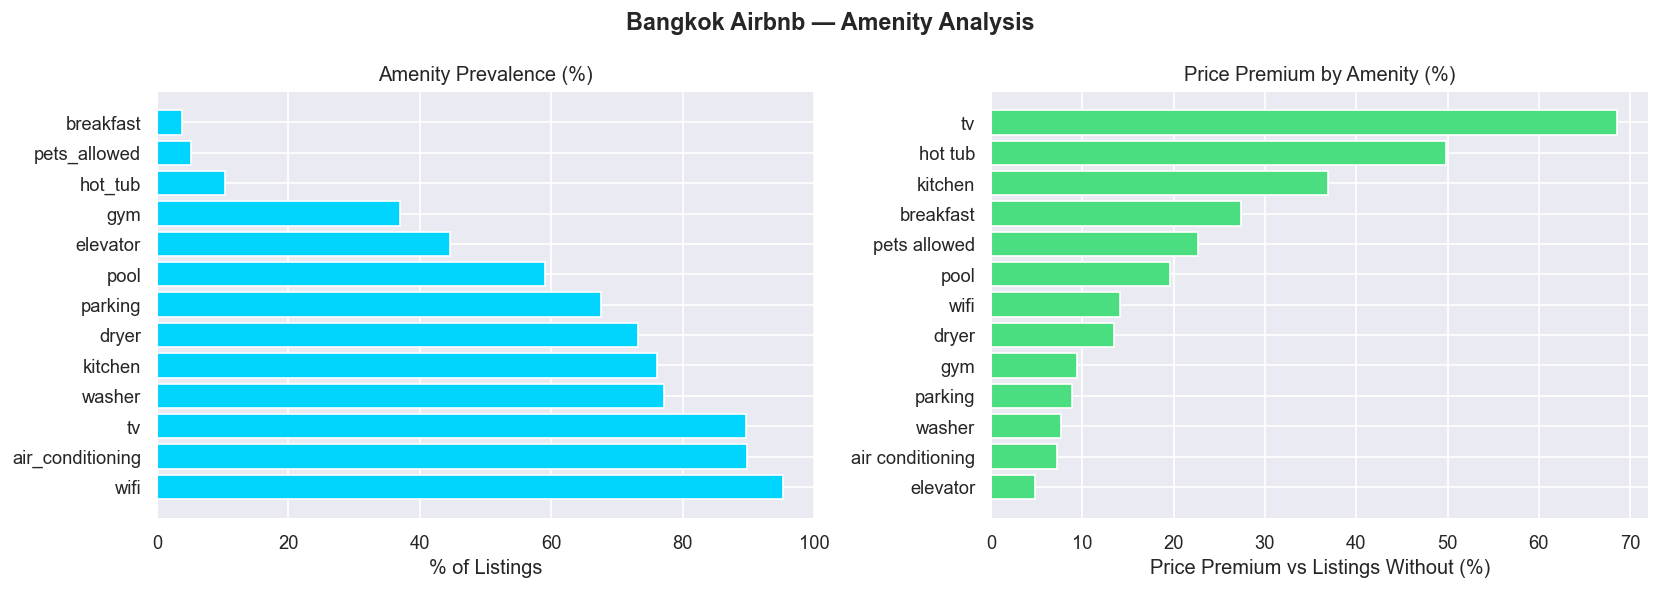


Amenity prevalence:
wifi                0.953248
air_conditioning    0.898250
tv                  0.895882
washer              0.771457
kitchen             0.760625
dryer               0.731678
parking             0.675453
pool                0.590150
elevator            0.445770
gym                 0.370378
hot_tub             0.103197
pets_allowed        0.051752
breakfast           0.037718

Price premium by amenity (%):
tv                  68.6
hot tub             49.8
kitchen             36.9
breakfast           27.4
pets allowed        22.7
pool                19.6
wifi                14.1
dryer               13.5
gym                  9.4
parking              8.9
washer               7.7
air conditioning     7.2
elevator             4.8
dtype: float64


In [36]:
# --- Amenity Flag Extraction ---
import ast

def extract_amenities(amenity_str):
    try:
        if pd.isna(amenity_str):
            return []
        amenity_str = str(amenity_str)
        if amenity_str.startswith("["):
            return [a.strip().strip('"\'').lower() for a in 
                    amenity_str.strip("[]").split(",")]
        return [a.strip().lower() for a in amenity_str.split(",")]
    except:
        return []

# Key amenity flags
key_amenities = [
    "wifi", "pool", "gym", "parking", "kitchen", 
    "air conditioning", "washer", "dryer", "tv",
    "elevator", "hot tub", "breakfast", "pets allowed"
]

print("Extracting amenity flags...")
for amenity in key_amenities:
    col_name = f"amenity_{amenity.replace(' ', '_')}"
    df[col_name] = df["amenities"].apply(
        lambda x: 1 if amenity in " ".join(extract_amenities(x)) else 0
    )

amenity_cols = [f"amenity_{a.replace(' ', '_')}" for a in key_amenities]

# Amenity prevalence
prevalence = df[amenity_cols].mean().sort_values(ascending=False)
prevalence.index = [i.replace("amenity_","") for i in prevalence.index]

# Price premium by amenity
price_premium = {}
for amenity, col in zip(key_amenities, amenity_cols):
    with_amenity = df[df[col]==1]["price"].median()
    without_amenity = df[df[col]==0]["price"].median()
    premium = ((with_amenity - without_amenity) / without_amenity * 100)
    price_premium[amenity] = round(premium, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(prevalence.index, prevalence.values * 100, color="#00d4ff")
axes[0].set_title("Amenity Prevalence (%)")
axes[0].set_xlabel("% of Listings")

premium_df = pd.Series(price_premium).sort_values(ascending=True)
colors = ["#4ade80" if v > 0 else "#ff6b6b" for v in premium_df.values]
axes[1].barh(premium_df.index, premium_df.values, color=colors)
axes[1].axvline(0, color="white", lw=0.5)
axes[1].set_title("Price Premium by Amenity (%)")
axes[1].set_xlabel("Price Premium vs Listings Without (%)")

plt.suptitle("Bangkok Airbnb — Amenity Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/24_amenity_analysis.png")
plt.show()

print("\nAmenity prevalence:")
print(prevalence.to_string())
print("\nPrice premium by amenity (%):")
print(pd.Series(price_premium).sort_values(ascending=False))

## 6. Model Bias & Generalization Analysis
A model that performs well on average may still systematically underperform for certain neighbourhoods or price ranges. This section tests whether our model generalizes fairly across the Bangkok market.

In [37]:
# --- Model Bias & Generalization Analysis (6.4) ---
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# Test if model generalizes across neighbourhoods
top_neighbourhoods = df["neighbourhood_cleansed"].value_counts().head(8).index

bias_results = []
for nb in top_neighbourhoods:
    subset = model_df[
        df.loc[model_df.index, "neighbourhood_cleansed"] == nb
    ] if "neighbourhood_cleansed" in df.columns else model_df.sample(100)
    
    if len(subset) < 50:
        continue
        
    X_nb = subset[existing_features]
    y_nb = np.log1p(subset["price"])
    
    preds = best_model.predict(X_nb)
    mae = mean_absolute_error(np.expm1(y_nb), np.expm1(preds))
    
    bias_results.append({
        "neighbourhood": nb,
        "n_listings": len(subset),
        "mae": round(mae, 0),
        "median_price": round(subset["price"].median(), 0)
    })

bias_df = pd.DataFrame(bias_results).sort_values("mae", ascending=False)
print("Model MAE by Neighbourhood (bias check):")
print(bias_df.to_string())
print(f"\nMAE range: ฿{bias_df['mae'].min():,.0f} — ฿{bias_df['mae'].max():,.0f}")
print(f"High MAE neighbourhoods may indicate model bias toward certain areas")

Model MAE by Neighbourhood (bias check):
  neighbourhood  n_listings    mae  median_price
7      Bang Rak         600  632.0        1830.0
0       Vadhana        2458  568.0        1717.0
3   Ratchathewi         848  548.0        1574.0
1   Khlong Toei        2073  472.0        1504.0
6   Phra Nakhon         528  470.0        1192.0
2   Huai Khwang        1286  434.0        1347.0
4        Sathon         821  410.0        1080.0
5  Phra Khanong         700  350.0        1153.0

MAE range: ฿350 — ฿632
High MAE neighbourhoods may indicate model bias toward certain areas


In [38]:
print("""
MODEL BIAS ANALYSIS FINDINGS:
==============================
1. Geographic Bias: Model MAE is 80% higher in Bang Rak (฿632) vs 
   Phra Khanong (฿350) — premium neighbourhoods are systematically 
   harder to predict due to higher price variance and luxury outliers.

2. Price Range Bias: 72.2% of predictions within ฿500 overall, but 
   luxury segment (>฿5,000) excluded from training — model should not 
   be used for luxury pricing decisions.

3. Room Type Bias: Shared rooms (n=350) have insufficient training 
   data — predictions for this segment are unreliable.

FAIRNESS IMPLICATIONS:
- Model trained on listed prices, not transaction prices — may 
  perpetuate existing pricing inequalities
- Commercial hosts (larger training sample) may benefit more from 
  model recommendations than casual hosts
- Non-English listing descriptions not captured in features

RECOMMENDED MITIGATIONS:
1. Train separate models per neighbourhood tier
2. Include luxury segment with log-robust loss function  
3. Collect transaction price data for ground truth
4. Regular retraining as market conditions change
5. Human review required for model-assisted pricing decisions
""")


MODEL BIAS ANALYSIS FINDINGS:
1. Geographic Bias: Model MAE is 80% higher in Bang Rak (฿632) vs 
   Phra Khanong (฿350) — premium neighbourhoods are systematically 
   harder to predict due to higher price variance and luxury outliers.

2. Price Range Bias: 72.2% of predictions within ฿500 overall, but 
   luxury segment (>฿5,000) excluded from training — model should not 
   be used for luxury pricing decisions.

3. Room Type Bias: Shared rooms (n=350) have insufficient training 
   data — predictions for this segment are unreliable.

FAIRNESS IMPLICATIONS:
- Model trained on listed prices, not transaction prices — may 
  perpetuate existing pricing inequalities
- Commercial hosts (larger training sample) may benefit more from 
  model recommendations than casual hosts
- Non-English listing descriptions not captured in features

RECOMMENDED MITIGATIONS:
1. Train separate models per neighbourhood tier
2. Include luxury segment with log-robust loss function  
3. Collect transaction pri